In [1]:
import cirq
import sys
import matplotlib as mpl
from copy import deepcopy
mpl.rcParams.update(
    {
        "font.size": 8,
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "lines.linewidth": 2,
        "axes.linewidth": 1.5,
        "grid.alpha": 0.4,
        "figure.dpi": 150,
    }
)

In [2]:
sys.path.append('../')
import resource_estimation as res
import scripts.layout_figures as lfs

In [3]:
# circuit = cirq.Circuit(cirq.MatrixGate(cirq.testing.random_special_unitary(4)).on(*cirq.LineQubit.range(2)))
circuit = cirq.testing.random_circuit(10, 10, 1, random_state=19)
circuit

┌───────┐   ┌───┐   ┌──────┐   ┌──────────┐       ┌────┐   ┌───┐       ┌───────┐   ┌───┐
0: ────X────────────@──────Z───────────────iSwap────H──────@──────X───────────@──────────────────
                    │                      │               │      │           │
1: ────×───────────Z┼──────S──────────S────┼────────Z──────┼──────┼──────Z────┼────×───────×─────
       │            │                      │               │      │           │    │       │
2: ────┼@───────────┼──────@──────────Z────┼────────Z─────@┼──────@──────T────┼────┼S─────T┼─────
       ││           │      │               │              ││                  │    │       │
3: ────┼┼iSwap─────H┼──────┼iSwap──────────┼────────Y────S┼┼──────H──────H────@────┼──────@┼─────
       │││          │      ││              │              ││                       │      ││
4: ────┼@┼──────────┼@─────X┼─────────X────┼────────Y────×┼┼───────X─────@────T────┼──────┼┼Z────
       │ │          ││      │              │             │││       │     │         │      ││
5: ────┼Y┼─────────X┼┼─────Y┼──────────────iSwap────S────┼┼┼Z─────X┼─────@────iSwap┼──────┼×─────
       │ │          ││      │                            │││      ││          │    │      │
6: ────┼─┼──────────┼X──────┼─────────Y──────────────────┼X┼──────┼┼@────@────┼────×──────X──────
       │ │          │       │                            │ │      │││    │    │
7: ────×─┼──────────X──────H┼─────────iSwap─────────S────┼Z┼──────@┼┼────@────iSwap───────S──────
         │                  │         │                  │ │       ││
8: ──────iSwap─────T────────iSwap─────iSwap─────────X────┼─@───────┼@────H────────────────×──────
                                                         │         │                      │
9: ────T───────────Z───────Z──────────S─────────────T────×─────────@─────X────S───────────×──────
      └───────┘   └───┘   └──────┘   └──────────┘       └────┘   └───┘       └───────┘   └───┘

In [4]:
distillery = res.layout.Distillery(circuit, num_s_factories=7, num_t_factories=5)

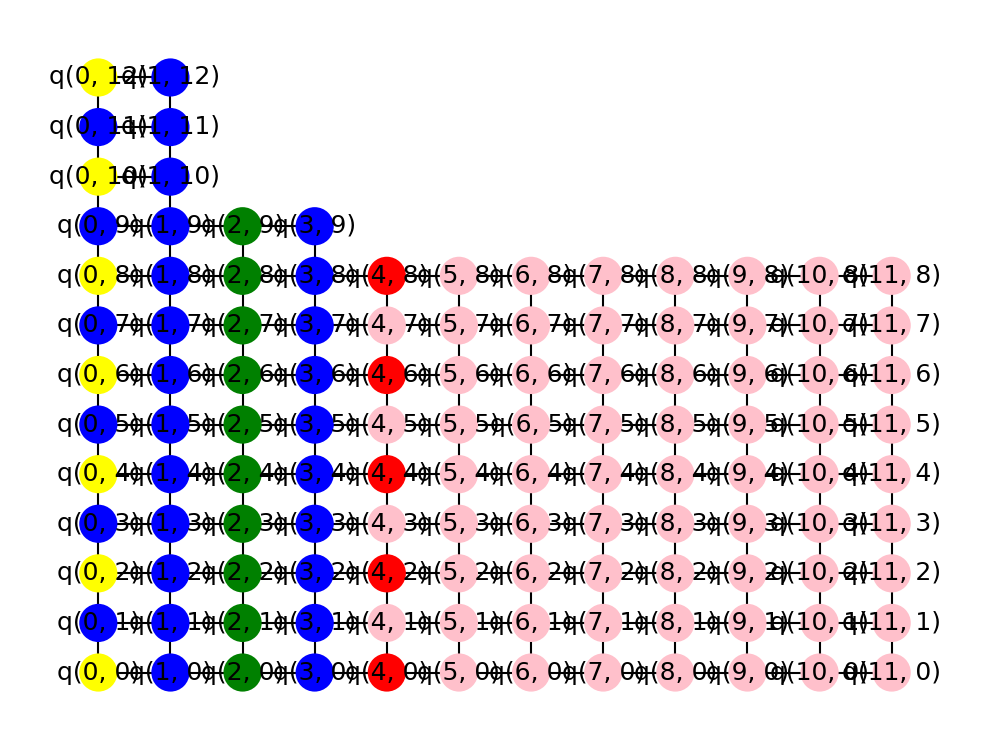

In [5]:
distillery.draw()

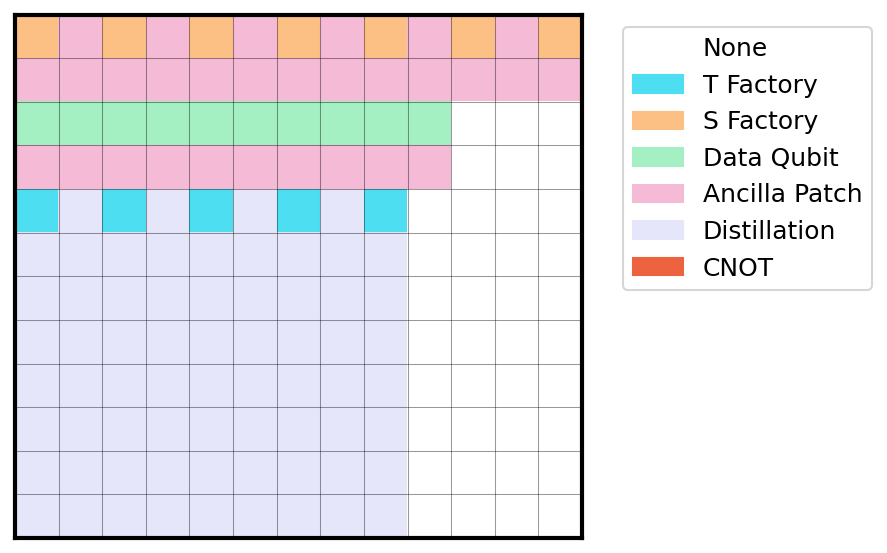

In [6]:
category_colors = {
    "None": "#ffffff",
    "T Factory": "#4ddef1",
    "S Factory": "#fcc084",
    "Data Qubit": "#a4f0c2",
    "Ancilla Patch": "#f5bad6",
    "Distillation": "#E6E6FA",
    "CNOT": "#ed6340"
}
fig, ax, im = lfs.plot_layout(distillery, category_colors=category_colors, transpose=False)

In [7]:
to_plot = deepcopy(distillery)
to_plot.reload_factories(ftype='t')
example_path = to_plot.route_cnot(cirq.GridQubit(2, 0), cirq.GridQubit(4, 4))
print(example_path)
for node in example_path:
    to_plot.layout_graph.nodes[node]['patch_type'] = "CNOT"
    if "ftype" in to_plot.layout_graph.nodes[node]:
        del to_plot.layout_graph.nodes[node]['ftype']

[cirq.GridQubit(2, 0), cirq.GridQubit(3, 0), cirq.GridQubit(3, 1), cirq.GridQubit(3, 2), cirq.GridQubit(3, 3), cirq.GridQubit(3, 4), cirq.GridQubit(4, 4)]


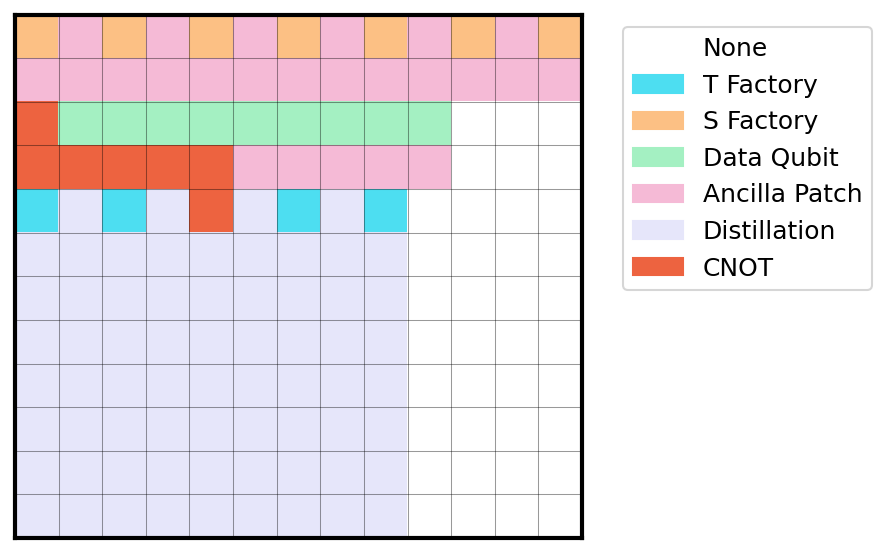

In [8]:
fig, ax, im = lfs.plot_layout(to_plot, category_colors=category_colors, transpose=False, show_pixel_grid=True, grid_linewidth=0.5)